In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
sales = pd.read_csv('Deven_linear_advertising_sales.csv')

sales.head()

,advertising_budget,sales
0,3563.56,125.06
1,1331.98,90.28
2,6486.08,278.33
3,5524.11,353.70
4,1463.31,34.00


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   advertising_budget  30 non-null     float64
 1   sales               30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [5]:
sales.isnull().sum()

advertising_budget    0
sales                 0
dtype: int64

In [6]:
sales.describe()

,advertising_budget,sales
count,30.000000,30.000000
mean,4852.084000,241.403333
std,2520.035436,129.799486
min,1149.290000,34.000000
25%,3063.530000,125.440000
50%,4857.560000,236.655000
75%,6699.015000,345.605000
max,9870.850000,499.400000


In [7]:
sales.shape

(30, 2)

<Axes: ylabel='advertising_budget'>

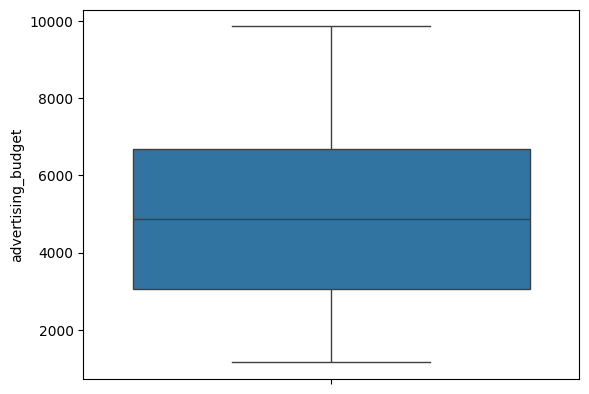

In [8]:
sns.boxplot(sales['advertising_budget'])

<Axes: ylabel='sales'>

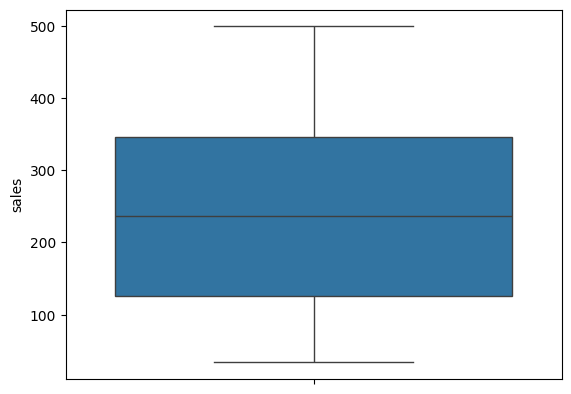

In [9]:
sns.boxplot(sales['sales'])

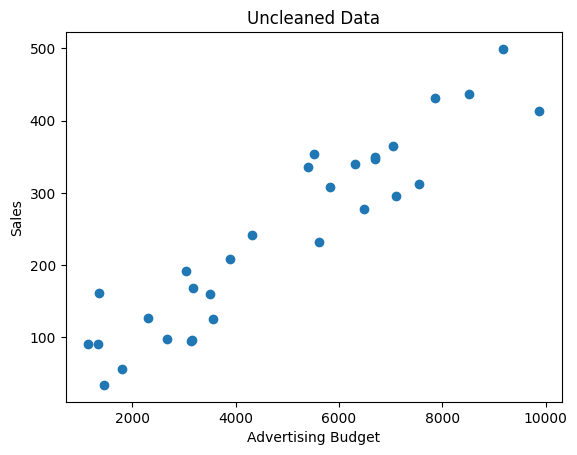

In [10]:
plt.scatter(sales['advertising_budget'], sales['sales'])
plt.title('Uncleaned Data')
plt.xlabel('Advertising Budget')
plt.ylabel('Sales')
plt.show()

In [11]:
Q1 = sales['advertising_budget'].quantile(0.25)
Q3 = sales['advertising_budget'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_clean = sales[(sales['advertising_budget']>=lower_bound) & (sales['advertising_budget']<= upper_bound)]

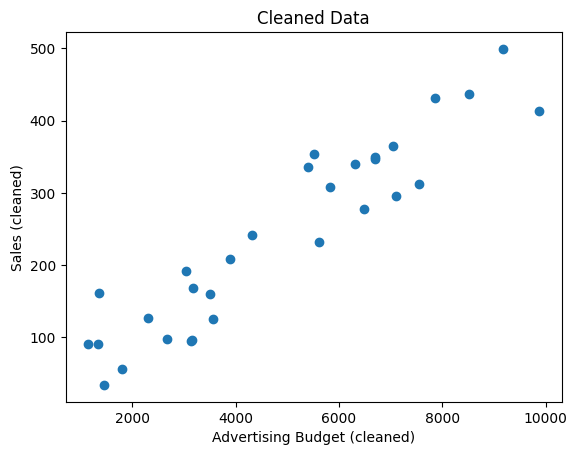

In [12]:
plt.scatter(sales_clean['advertising_budget'], sales_clean['sales'])
plt.title("Cleaned Data")
plt.xlabel("Advertising Budget (cleaned)")
plt.ylabel('Sales (cleaned)')
plt.show()

In [13]:
X = sales_clean[['advertising_budget']]
y = sales_clean[['sales']]

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=21)

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
print('Cefficient:', model.coef_)
print('Intercept:', model.intercept_)

Cefficient: [[0.04771211]]
Intercept: [12.04969744]


In [18]:
y_pred = model.predict(X_test)

In [19]:
eval = r2_score(y_test, y_pred)
eval

0.9367824924943402

In [20]:
from joblib import dump

In [21]:
dump(model, r"C:\Users\ADMIN\OneDrive\Desktop\sales_prediction\mock_api.joblib")

['C:\\Users\\ADMIN\\OneDrive\\Desktop\\sales_prediction\\mock_api.joblib']